# Model Performance for 2024

#### In order to measure the performance of the models and methodology, I performed a run on all of the data, except this time cutting off the historical data at 12/31/2023 and predicting 2024.  This program will look at the predicted 2024 values versus the actual 2024 values and measure how good the predictions are.

In [97]:
# needed for data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import geopandas as gpd
import datetime
import ipywidgets as widgets
from IPython.display import display, clear_output

### VARIABLES

In [98]:
PREDICT_FILE = 'SnowmanData_predict_2024_only.csv'
ACTUAL_FILE = 'SnowmanData_actual_2024_only.csv'
SHP_FILE = 's_18mr25.shp'
RADIUS_IN_KILOMETERS = 50
FIG_SIZE = (40,40)

### Get statistics

In [99]:
# Read the CSV files into DataFrames
predict_df = pd.read_csv(PREDICT_FILE)
actual_df = pd.read_csv(ACTUAL_FILE)

# rename Snowman column
predict_df.rename(columns={'SNOWMAN': 'PREDICTION'}, inplace=True)
actual_df.rename(columns={'SNOWMAN': 'ACTUAL'}, inplace=True)

# Merge the DataFrames on the 'DATE', 'LATITUDE', 'LONGITUDE' columns
merged_df = pd.merge(predict_df, actual_df, on=['DATE', 'LATITUDE', 'LONGITUDE'], how='inner')

# reorder columns
merged_df = merged_df[['LATITUDE', 'LONGITUDE', 'DATE', 'PREDICTION', 'ACTUAL']]

# order by latitude, longitude, date
merged_df = merged_df.sort_values(by=['LATITUDE', 'LONGITUDE', 'DATE'])

In [100]:
# Create true positives column
merged_df['TP'] = np.where((merged_df['PREDICTION'] == 1) & (merged_df['ACTUAL'] == 1), 1, 0)

# Create true negatives column
merged_df['TN'] = np.where((merged_df['PREDICTION'] == 0) & (merged_df['ACTUAL'] == 0), 1, 0)

# Create false positives column
merged_df['FP'] = np.where((merged_df['PREDICTION'] == 1) & (merged_df['ACTUAL'] == 0), 1, 0)

# Create false negatives column
merged_df['FN'] = np.where((merged_df['PREDICTION'] == 0) & (merged_df['ACTUAL'] == 1), 1, 0)


In [101]:
print(merged_df.head())

         LATITUDE  LONGITUDE        DATE  PREDICTION  ACTUAL  TP  TN  FP  FN
1064870  26.17912   -98.2445  2024-01-06           0       0   0   1   0   0
1064871  26.17912   -98.2445  2024-01-07           0       0   0   1   0   0
1064872  26.17912   -98.2445  2024-01-08           0       0   0   1   0   0
1064873  26.17912   -98.2445  2024-01-09           0       0   0   1   0   0
1064874  26.17912   -98.2445  2024-01-10           0       0   0   1   0   0


In [102]:
sum_TP = merged_df['TP'].sum()
sum_TN = merged_df['TN'].sum()
sum_FP = merged_df['FP'].sum()
sum_FN = merged_df['FN'].sum()
print(f'TP: {sum_TP}')
print(f'TN: {sum_TN}')
print(f'FP: {sum_FP}')
print(f'FN: {sum_FN}')

TP: 26577
TN: 1028043
FP: 45615
FN: 31658


In [103]:
# Calculate accuracy   
# Accuracy = (TP + TN) / (TP + TN + FP + FN)
accuracy = (sum_TP + sum_TN) / (sum_TP + sum_TN + sum_FP + sum_FN)
print('Accuracy - how many of the predictions were correct')
print(f'{accuracy:.5f}')
print('\n')
# Calculate accuracy if I had just chosen negative all the time
# Accuracy = (TN + FP) / (TP + TN + FP + FN)
accuracy_neg = (sum_FP + sum_TN) / (sum_TP + sum_TN + sum_FP + sum_FN)
print(f'Accuracy, if we just chose negative all the time: ')
print(f'{accuracy_neg:.5f}')
print('\n')
# Calculate precision
# Precision = TP / (TP + FP)
precision = sum_TP / (sum_TP + sum_FP)
print('Precision - how many of the predicted positives were actually positive')
print(f'{precision:.5f}')
print('\n')
# Calculate recall
# Recall = TP / (TP + FN)
recall = sum_TP / (sum_TP + sum_FN)
print('Recall (sensitivity) - how many of the actual positives were predicted as positive')
print(f'{recall:.5f}')
print('\n')
# Calculate F1 score
# F1 Score = 2 * (Precision * Recall) / (Precision + Recall)
f1_score = (2 * precision * recall) / (precision + recall)
print('F1 Score - the harmonic mean of precision and recall')
print(f'{f1_score:.5f}')
print('\n')
# Calculate specificity
# Specificity = TN / (TN + FP)
specificity = sum_TN / (sum_TN + sum_FP)
print('Specificity - how many of the actual negatives were predicted as negative')
print(f'{specificity:.5f}')
print('\n')

Accuracy - how many of the predictions were correct
0.93173


Accuracy, if we just chose negative all the time: 
0.94855


Precision - how many of the predicted positives were actually positive
0.36814


Recall (sensitivity) - how many of the actual positives were predicted as positive
0.45638


F1 Score - the harmonic mean of precision and recall
0.40754


Specificity - how many of the actual negatives were predicted as negative
0.95751




In [104]:
# Calculate false positive rate
# False Positive Rate = FP / (FP + TN)
false_positive_rate = sum_FP / (sum_FP + sum_TN)
print('False Positive Rate - how many of the actual negatives were predicted as positive')
print(f'{false_positive_rate:.5f}')
print('\n')
# Calculate false negative rate
# False Negative Rate = FN / (FN + TP)
false_negative_rate = sum_FN / (sum_FN + sum_TP)
print('False Negative Rate - how many of the actual positives were predicted as negative')
print(f'{false_negative_rate:.5f}')
print('\n')

False Positive Rate - how many of the actual negatives were predicted as positive
0.04249


False Negative Rate - how many of the actual positives were predicted as negative
0.54362




### Set up the map

In [105]:
# create the geodataframe
usa_gdf = gpd.read_file(SHP_FILE)

# remove areas that are not part of the lower 48 states
usa_gdf = usa_gdf.drop([2, 10, 36, 43, 51, 53, 54, 55, 56, 58])

# crs = Coordinate Reference System
# epsg (European Petroleum Survey Group) is a standard for referencing coordinate systems
# epsg:3395 is the Mercator projection
# this is the projection used by Google Maps
usa_gdf = usa_gdf.to_crs('epsg:3395')

### Set up the GeoDataFrame

In [106]:
# epsg:4326 is the WGS 84 coordinate system used by GPS
# this is the coordinate system used by most mapping software
merged_gdf = gpd.GeoDataFrame(merged_df, geometry=gpd.points_from_xy(merged_df.LONGITUDE, merged_df.LATITUDE), crs='epsg:4326')

# convert the coordinate system to epsg:3395 to be consistent with the usa_gdf
merged_gdf = merged_gdf.to_crs('epsg:3395')

# create a buffer around the snowman points to designate the region of interest
# the buffer is in meters, so 50000 is 50 km
merged_gdf['geometry'] = merged_gdf.buffer(RADIUS_IN_KILOMETERS * 1000)

# FUNCTIONS

In [107]:
# Function to plot data for a selected date
def plot_date(selected_date):
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    ax.set_facecolor('black')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    
    # create the plot title
    title = 'Model Performance ' + selected_date
    ax.set_title(title, fontdict={'fontsize': '64'})

    # filter to the date selected by the user
    tmp_gdf = merged_gdf[merged_gdf['DATE'] == selected_date]

    # create the legend
    legend_elements = [Line2D([0], [0], marker='o', color='w', label='True Positive', markerfacecolor='white', markersize=20),
                       Line2D([0], [0], marker='o', color='w', label='True Negative', markerfacecolor='grey', markersize=20),
                       Line2D([0], [0], marker='o', color='w', label='False Positive', markerfacecolor='red', markersize=20),
                       Line2D([0], [0], marker='o', color='w', label='False Negative', markerfacecolor='orange', markersize=20)]
    legend = ax.legend(handles=legend_elements, loc='lower right', fontsize='32',
                       title = 'Each circle is ' + str(RADIUS_IN_KILOMETERS) + ' km in radius centered on a weather station')
    plt.setp(legend.get_title(), fontsize='20')

    # create and plot the performance data
    FN_gdf = tmp_gdf[merged_gdf['FN'] == 1]
    FP_gdf = tmp_gdf[merged_gdf['FP'] == 1]
    TN_gdf = tmp_gdf[merged_gdf['TN'] == 1]
    TP_gdf = tmp_gdf[tmp_gdf['TP'] == 1]
    TN_gdf.plot(ax=ax, color='grey')
    FN_gdf.plot(ax=ax, color='orange')
    FP_gdf.plot(ax=ax, color='red')
    TP_gdf.plot(ax=ax, color='white')
    usa_gdf.plot(ax=ax, color='None', edgecolor='lightgreen') 

In [108]:
# Function to update plot on date picker change
def on_date_change(change):
    clear_output()
    plot_date(change['new'].strftime('%Y-%m-%d'))

# RUN

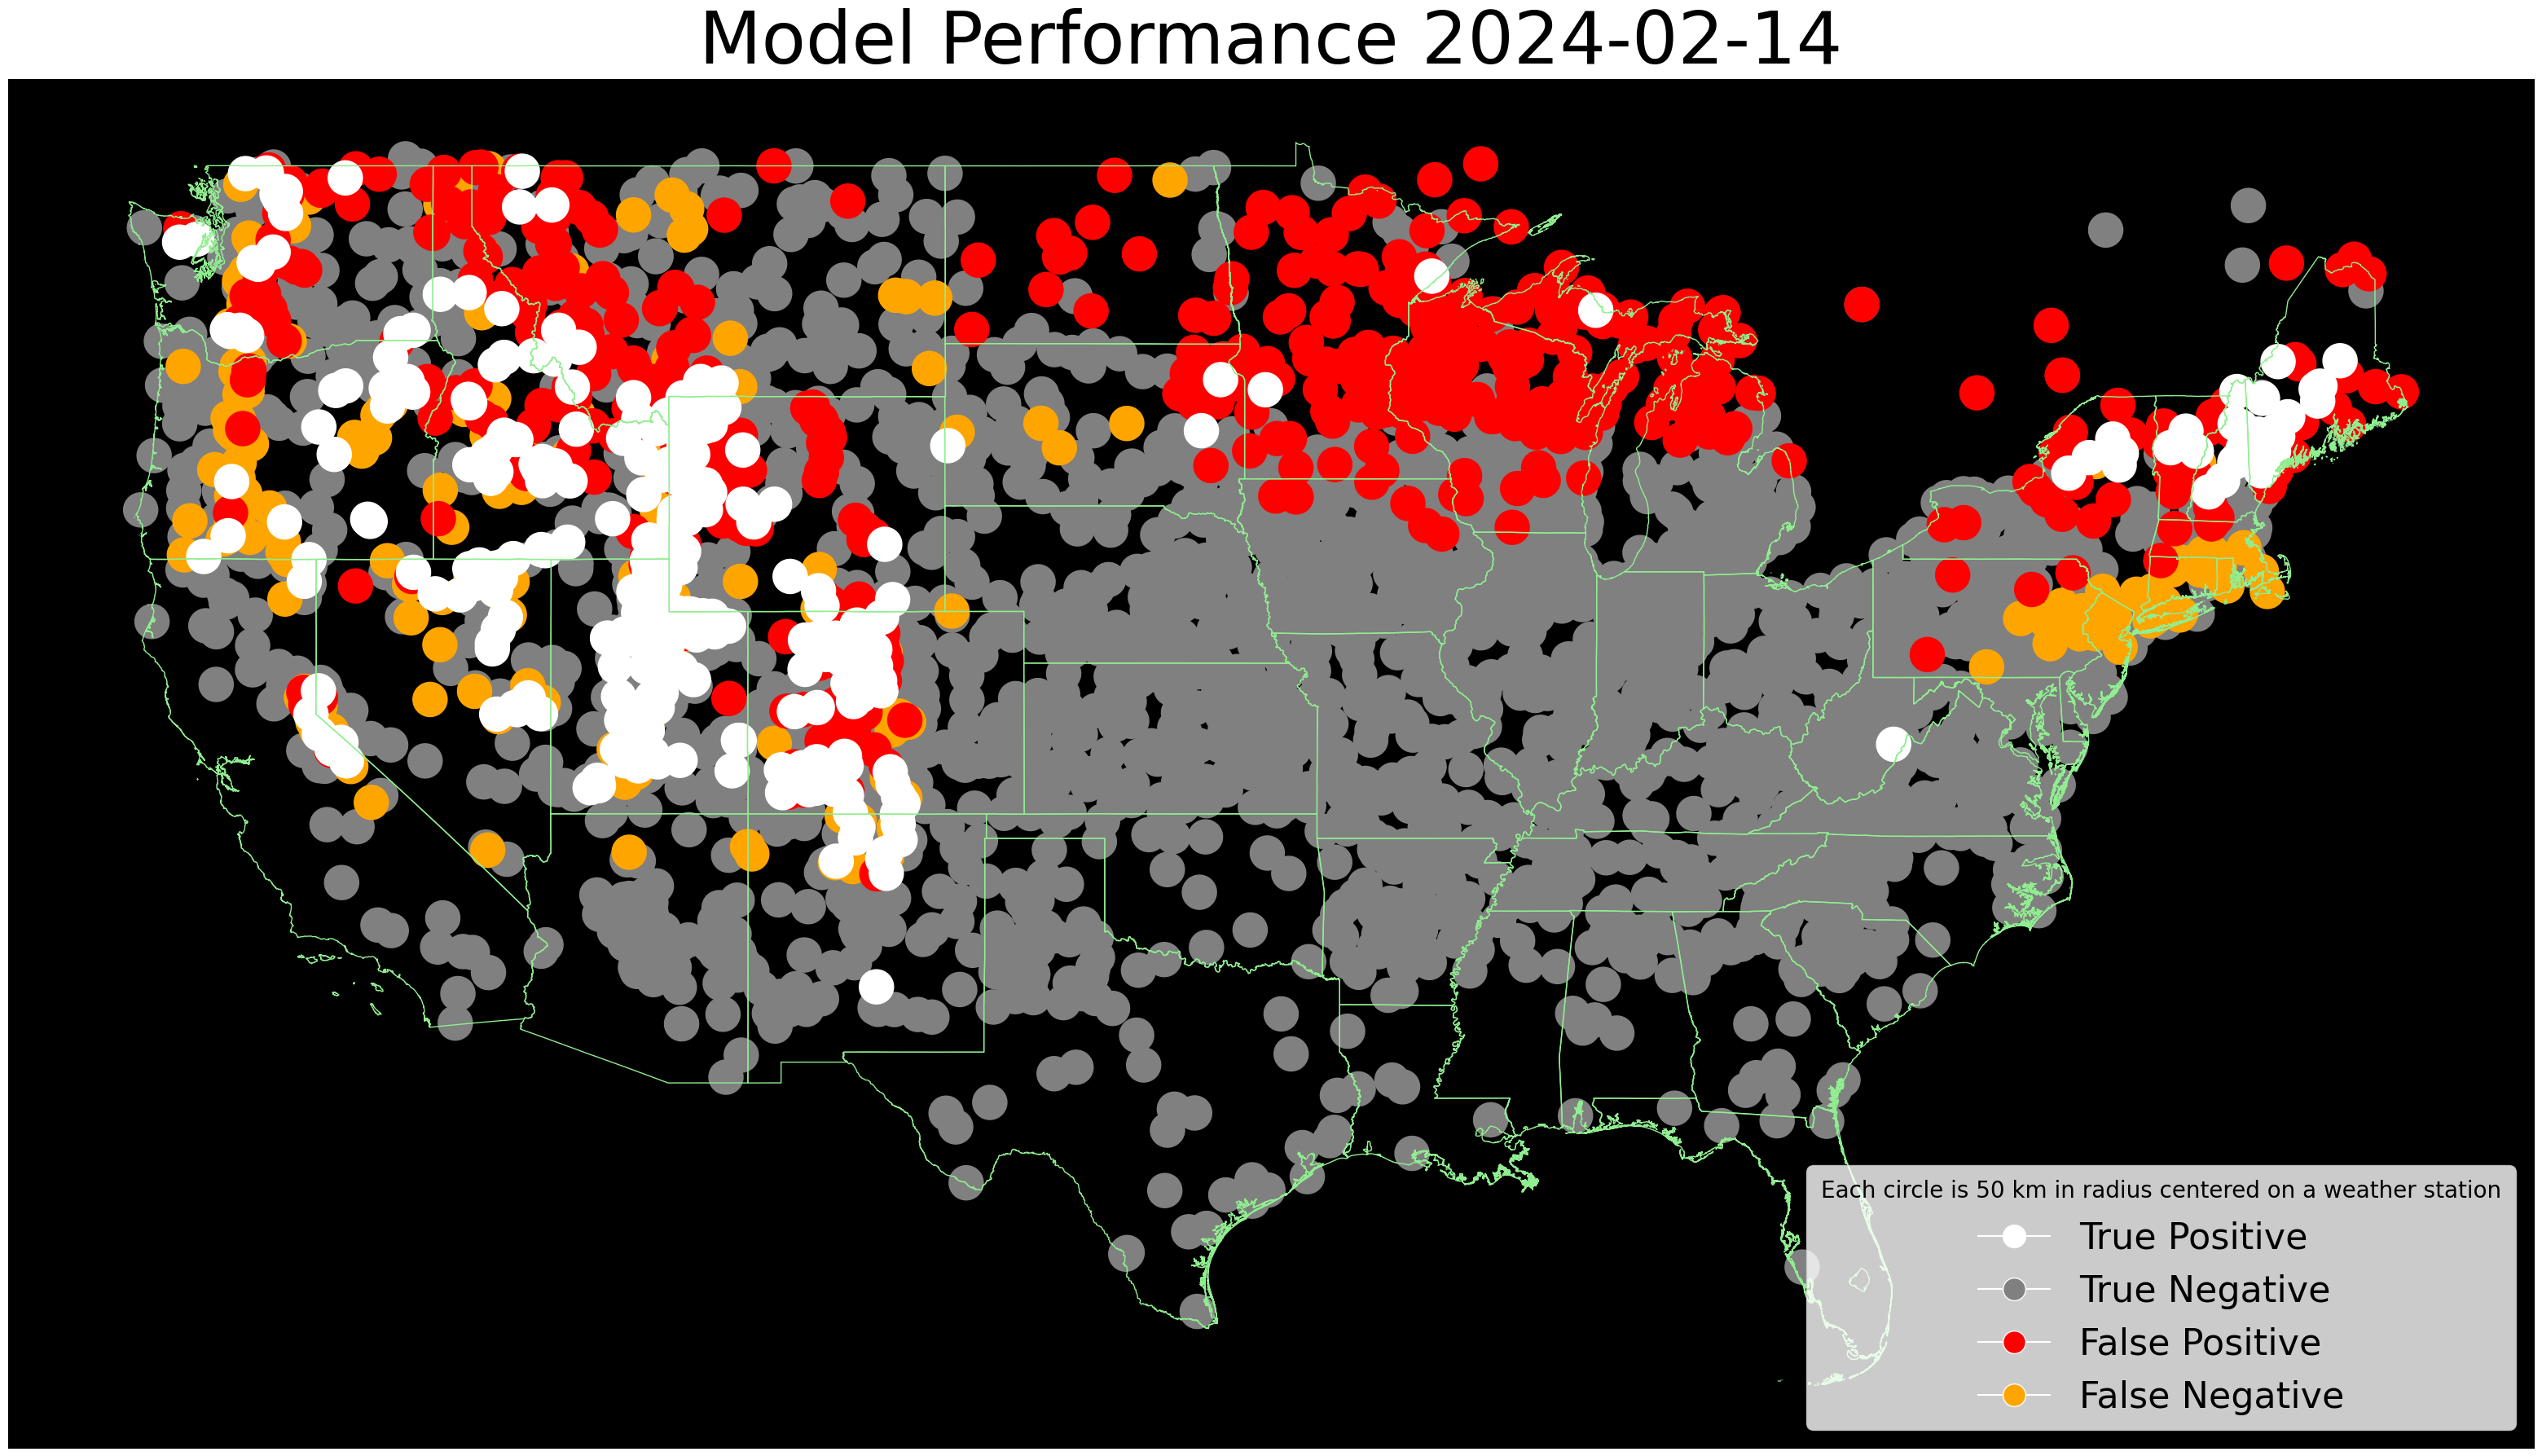

In [109]:
# Create a date selection widget
date_picker = widgets.DatePicker(
    description='Select a Date',
    disabled=False
)
# Watch for changes in the date selection widget
date_picker.observe(on_date_change, names='value')

In [110]:
# Display the date selection widget
display(widgets.HTML("<h3>Choose a date in 2024</h3>"))
display(date_picker)

HTML(value='<h3>Choose a date in 2024</h3>')

DatePicker(value=None, description='Select a Date', step=1)